### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import cv2
import pytesseract
import matplotlib.pyplot as plt

### Step 2: Constant

In [150]:
FILE_PATH = './data/LicensePlate00.jpg'
pytesseract.pytesseract.tesseract_cmd = 'E:/software/Tesseract-OCR/tesseract.exe'

### Step 3: Detect License Plate Number

In [109]:
image = cv2.imread(FILE_PATH)

In [110]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

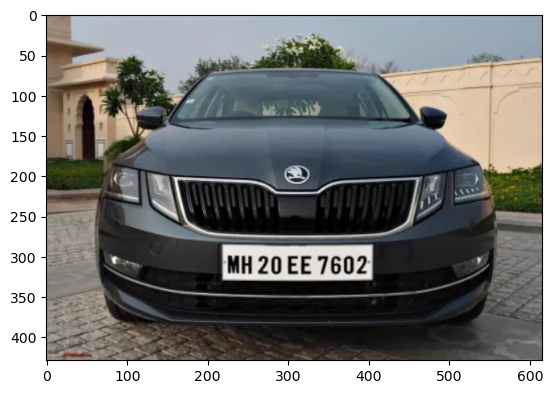

In [111]:
plt.imshow(image)

In [112]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

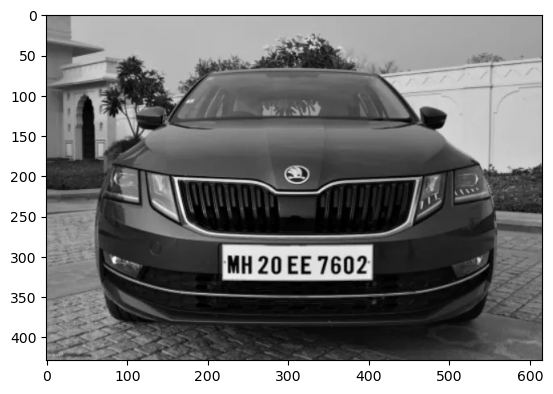

In [113]:
plt.imshow(gray, cmap='gray')

In [114]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

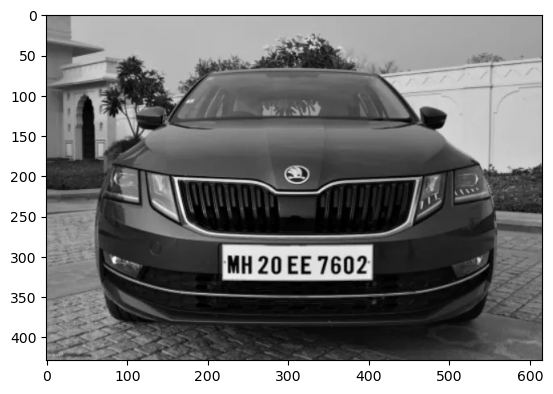

In [115]:
plt.imshow(gray, cmap='gray')

In [134]:
edges = cv2.Canny(blurred, 100, 200)

In [135]:
edges.shape

(429, 616)

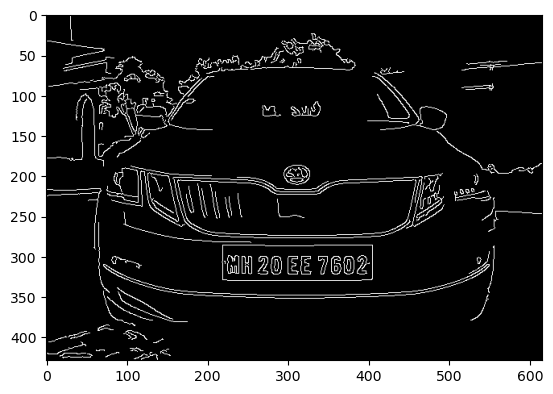

In [136]:
plt.imshow(edges, cmap='gray')

In [137]:
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [138]:
contours = sorted(contours, key=cv2.contourArea, reverse=True)

In [139]:
plate_contour = None
for contour in contours:
    epsilon = 0.02 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    
    if len(approx) == 4:
        plate_contour = approx
        break

In [140]:
if plate_contour is not None:
    x, y, w, h = cv2.boundingRect(plate_contour)
    plate_image = gray[y:y+h, x:x+w]
    _, thresh = cv2.threshold(
        plate_image,
        0,
        255,
        cv2.THRESH_BINARY+cv2.THRESH_OTSU
    )

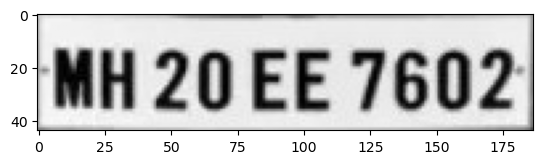

In [146]:
plt.imshow(plate_image, cmap='gray')

In [151]:
plate_number = pytesseract.image_to_string(thresh, config='--psm 8')

In [152]:
plate_number

'MH 20 EE 7602:\n'